# 02 — RQ1: pose estimation under the aerial domain gap
This notebook measures how much a COCO-pretrained pose model degrades under aerial
viewpoints and small person scales, and how much of that loss fine-tuning recovers.

- **Part A** — reference measurement: the PCK of RTMPose on ground-level COCO validation images.
- **Part B** — aerial PCK on UAV-Human (registration required:
  https://sutdcv.github.io/uav-human-web/ ; request the pose estimation subset).
- **Part C** — no-registration path: pseudo-label Okutama with a large teacher,
  fine-tune yolo11n-pose as student, evaluate on held-out video.


### Setup
The notebook requires a GPU runtime and the project source code.
1. Enable the GPU by selecting **Runtime → Change runtime type → T4 GPU**.
2. Archive the local `src/` and `scripts/` directories as `src.zip`
   (`cd Project && zip -r src.zip src scripts`), then either upload the archive
   in the cell below or place it in Drive and set `SRC_ZIP`.


In [1]:
# Environment.
!pip -q install ultralytics rtmlib onnxruntime-gpu
import torch, os
print('cuda:', torch.cuda.is_available())

# Project code: upload src.zip (or mount Drive and set SRC_ZIP).
from pathlib import Path
SRC_ZIP = None  # e.g. '/content/drive/MyDrive/sar_project/src.zip'
if SRC_ZIP is None:
    from google.colab import files
    up = files.upload()  # choose src.zip
    SRC_ZIP = next(iter(up))
!mkdir -p /content/project && unzip -q -o "$SRC_ZIP" -d /content/project
import sys
sys.path.insert(0, '/content/project/src')
sys.path.insert(0, '/content/project')
print('project code ready')

# Results are written to Drive so that they persist across the session.
from google.colab import drive
drive.mount('/content/drive')
OUT = Path('/content/drive/MyDrive/sar_project_results'); OUT.mkdir(parents=True, exist_ok=True)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.8/249.8 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 78.4 MB/s eta 0:00:00
cuda: True


Saving src.zip to src.zip
project code ready
Mounted at /content/drive


In [2]:
# Part A — ground-level reference PCK (evaluator validation)
import config
from pathlib import Path
config.RAW_DIR = Path('/content/data/raw'); config.RAW_DIR.mkdir(parents=True, exist_ok=True)
config.TABLES_DIR = OUT
!curl -sL -o /content/coco_ann.zip http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!cd /content/data/raw && unzip -q -o /content/coco_ann.zip annotations/person_keypoints_val2017.json
import eval_pose
eval_pose.RAW_DIR = config.RAW_DIR; eval_pose.TABLES_DIR = OUT
ref = eval_pose.validate_on_coco(max_persons=150, device='cuda')


Downloading: "https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/onnx_sdk/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504.zip" to /root/.cache/rtmlib/hub/checkpoints/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504.zip
100%|██████████| 48.4M/48.4M [00:02<00:00, 21.0MB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


load /root/.cache/rtmlib/hub/checkpoints/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504.onnx with onnxruntime backend
{'PCK': 0.95, 'alpha': 0.1, 'n_persons': 150, 'n_kpts': 1900, 'PCK_h0-25': nan, 'PCK_h25-50': nan, 'PCK_h50-100': 0.9, 'PCK_h100-inf': 0.9575757575757575, 'backend': 'rtmpose', 'dataset': 'COCO-val2017-subset (ground-level sanity check)'}
saved /content/drive/MyDrive/sar_project_results/pck_coco_sanity.json


In [3]:
# Okutama-Action direct downloads (public Dropbox folder, verified working).
# preview=<file>&dl=1 selects a single file from the shared folder.
OKUTAMA_BASE = ('https://www.dropbox.com/scl/fo/9qvpsb3fsamvqzsa12149/'
                'APTyV-f01XLnJ0WFpZSBLOE?preview={name}&rlkey=7u7131amaul29amyr4jbnnu03&dl=1')

def fetch_okutama(name, dest='/content/data/okutama'):
    import subprocess, pathlib
    d = pathlib.Path(dest); d.mkdir(parents=True, exist_ok=True)
    zp = d / name
    if not zp.exists():
        subprocess.run(['curl', '-L', '-o', str(zp), OKUTAMA_BASE.format(name=name)], check=True)
    subprocess.run(['unzip', '-q', '-o', str(zp), '-d', str(d)], check=True)
    return d


In [4]:
# Part B — UAV-Human aerial PCK
!pip -q install gdown
!gdown 1kWStmFjrN1Njf6mj4rTso6XPMULcFKS5 -O /content/PoseEstimation.zip
!mkdir -p /content/data/raw/uavhuman_pose && unzip -q -o /content/PoseEstimation.zip -d /content/data/raw/uavhuman_pose


Downloading...
From (original): https://drive.google.com/uc?id=1kWStmFjrN1Njf6mj4rTso6XPMULcFKS5
From (redirected): https://drive.google.com/uc?id=1kWStmFjrN1Njf6mj4rTso6XPMULcFKS5&confirm=t&uuid=13d37014-1fcd-4124-b2d0-384a36aa4c73
To: /content/PoseEstimation.zip
100% 1.55G/1.55G [00:20<00:00, 75.3MB/s]


In [5]:
# Zero-shot aerial PCK over all 22,476 frames.
# Ablation built in: `downscale` reduces the person size before pose estimation to probe the
# scale axis of the domain gap (a factor of 0.5 halves the size), not viewpoint alone.
import numpy as np, cv2
from data.uavhuman import iter_dataset
from pose import PoseEstimator
from eval_pose import pck

def aerial_pck(limit=None, downscale=1.0, device='cuda'):
    est = PoseEstimator(device=device)
    preds, gts, viss, boxes = [], [], [], []
    for img_path, persons in iter_dataset('/content/data/raw/uavhuman_pose', limit=limit):
        img = cv2.imread(str(img_path))
        if img is None: continue
        if downscale != 1.0:
            img = cv2.resize(img, None, fx=downscale, fy=downscale)
        for p in persons:
            box = p['box'] * downscale
            kp, _ = est(img, box[None])
            preds.append(kp[0]); gts.append(p['kpts'] * downscale)
            viss.append(p['vis']); boxes.append(box)
    return pck(np.stack(preds), np.stack(gts), np.stack(viss), np.stack(boxes))

aerial = aerial_pck(limit=None)             # full zero-shot aerial PCK
aerial_small = aerial_pck(limit=3000, downscale=0.35)  # small-person regime
print('AERIAL zero-shot:', aerial)
print('AERIAL @0.35 scale:', aerial_small)  # compare both against Part A


load /root/.cache/rtmlib/hub/checkpoints/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504.onnx with onnxruntime backend
Skipping keypoint with missing coordinates: {'from_name': 'kp-1', 'id': 'sBgMyR8N7u', 'original_height': 1080, 'original_width': 1920, 'parent_id': None, 'source': '$img', 'to_name': 'img-1', 'type': 'keypointlabels', 'value': {'format': 'rle', 'keypointlabels': ['leftShoulder'], 'rle': []}}
Skipping keypoint with missing coordinates: {'from_name': 'kp-1', 'id': 'JaRPJ-lsMJ', 'original_height': 1080, 'original_width': 1920, 'parent_id': None, 'source': '$img', 'to_name': 'img-1', 'type': 'keypointlabels', 'value': {'format': 'rle', 'keypointlabels': ['rightAnkle'], 'rle': []}}
Skipping keypoint with missing coordinates: {'from_name': 'kp-1', 'id': 'FxhgKZRrfe', 'original_height': 1080, 'original_width': 1920, 'parent_id': None, 'source': '$img', 'to_name': 'img-1', 'type': 'keypointlabels', 'value': {'format': 'rle', 'keypointlabels': ['rightEar'], 'rle':

In [6]:
# Part C — pseudo-label Okutama -> fine-tune yolo11n-pose (student)
import numpy as np, cv2, sys
fetch_okutama('Sample.zip')          # sample run; use TrainSetVideos.zip for the full run
from data.okutama import parse_annotations
from pose import PoseEstimator

video = '/content/data/okutama/1.1.1.mov'
labels = parse_annotations('/content/data/okutama/1.1.1.txt')
est = PoseEstimator(device='cuda')   # teacher (substitute RTMPose-l for a stronger teacher)

# Build a YOLO-pose dataset: crops around GT boxes + teacher keypoints
from pathlib import Path
ds = Path('/content/data/okutama_pose'); (ds/'images/train').mkdir(parents=True, exist_ok=True)
(ds/'labels/train').mkdir(parents=True, exist_ok=True)
(ds/'images/val').mkdir(parents=True, exist_ok=True); (ds/'labels/val').mkdir(parents=True, exist_ok=True)
cap = cv2.VideoCapture(video); idx = 0; n = 0
while True:
    ok, img = cap.read()
    if not ok: break
    if idx in labels and idx % 5 == 0:
        H, W = img.shape[:2]
        boxes = np.array([b.box for b in labels[idx]], np.float32)
        kpts, scores = est(img, boxes)
        split = 'val' if idx % 25 == 0 else 'train'
        lines = []
        for (x1,y1,x2,y2), kp, sc in zip(boxes, kpts, scores):
            if sc.mean() < 0.35: continue   # keep confident pseudo-labels only
            cx,cy,w,h = ((x1+x2)/2/W,(y1+y2)/2/H,(x2-x1)/W,(y2-y1)/H)
            ks = ' '.join(f'{x/W:.5f} {y/H:.5f} {2 if s>0.35 else 0}' for (x,y),s in zip(kp,sc))
            lines.append(f'0 {cx:.5f} {cy:.5f} {w:.5f} {h:.5f} ' + ks)
        if lines:
            cv2.imwrite(str(ds/f'images/{split}/{idx:06d}.jpg'), img)
            (ds/f'labels/{split}/{idx:06d}.txt').write_text('\n'.join(lines))
            n += 1
    idx += 1
cap.release(); print(n, 'pseudo-labeled frames')
(ds/'okutama_pose.yaml').write_text(f'path: {ds}\ntrain: images/train\nval: images/val\nkpt_shape: [17, 3]\nnames:\n  0: person\n')


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


load /root/.cache/rtmlib/hub/checkpoints/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504.onnx with onnxruntime backend
232 pseudo-labeled frames


107

In [7]:
# Student fine-tune + PCK before/after vs teacher on the val frames
from ultralytics import YOLO
student = YOLO('yolo11n-pose.pt')
student.train(data=str(ds/'okutama_pose.yaml'), epochs=20, imgsz=1280, batch=8,
              device=0, project='/content/runs', name='pose_ft', exist_ok=True)
!cp /content/runs/pose_ft/weights/best.pt {OUT}/yolo11n_pose_okutama.pt


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/okutama_pose/okutama_pose.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5,

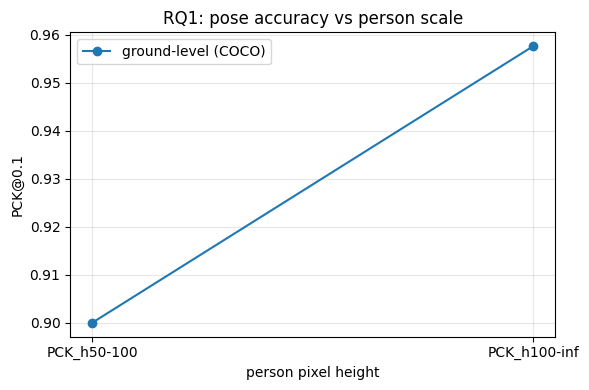

In [8]:
# Stratified PCK plot (the RQ1 headline figure)
import json, matplotlib.pyplot as plt
# fill with your measured values: ground-level (Part A), aerial zero-shot,
# aerial fine-tuned (Part B/C)
results = {'ground-level (COCO)': ref}
fig, ax = plt.subplots(figsize=(6,4))
bins = [k for k in ref if k.startswith('PCK_h')]
for name, m in results.items():
    ax.plot(bins, [m[b] for b in bins], marker='o', label=name)
ax.set_xlabel('person pixel height'); ax.set_ylabel(f"PCK@{ref['alpha']}")
ax.set_title('RQ1: pose accuracy vs person scale'); ax.legend(); ax.grid(alpha=.3)
fig.tight_layout(); fig.savefig(OUT / 'rq1_pck_vs_scale.png', dpi=150)
